In [1]:
import numpy as np
import pandas as pd
import timeit
import string
from skbio.stats.composition._ancombc2 import ancombc, ancombc2

In [2]:
import matplotlib.pyplot as plt
from matplotlib import ticker
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [3]:
cmap = plt.colormaps['tab20']
colors = cmap.colors[:4] # orange: ancom-bc2, blue: ancom-bc, dark: python, light: r

***
### Benchmark results on simulated dataset

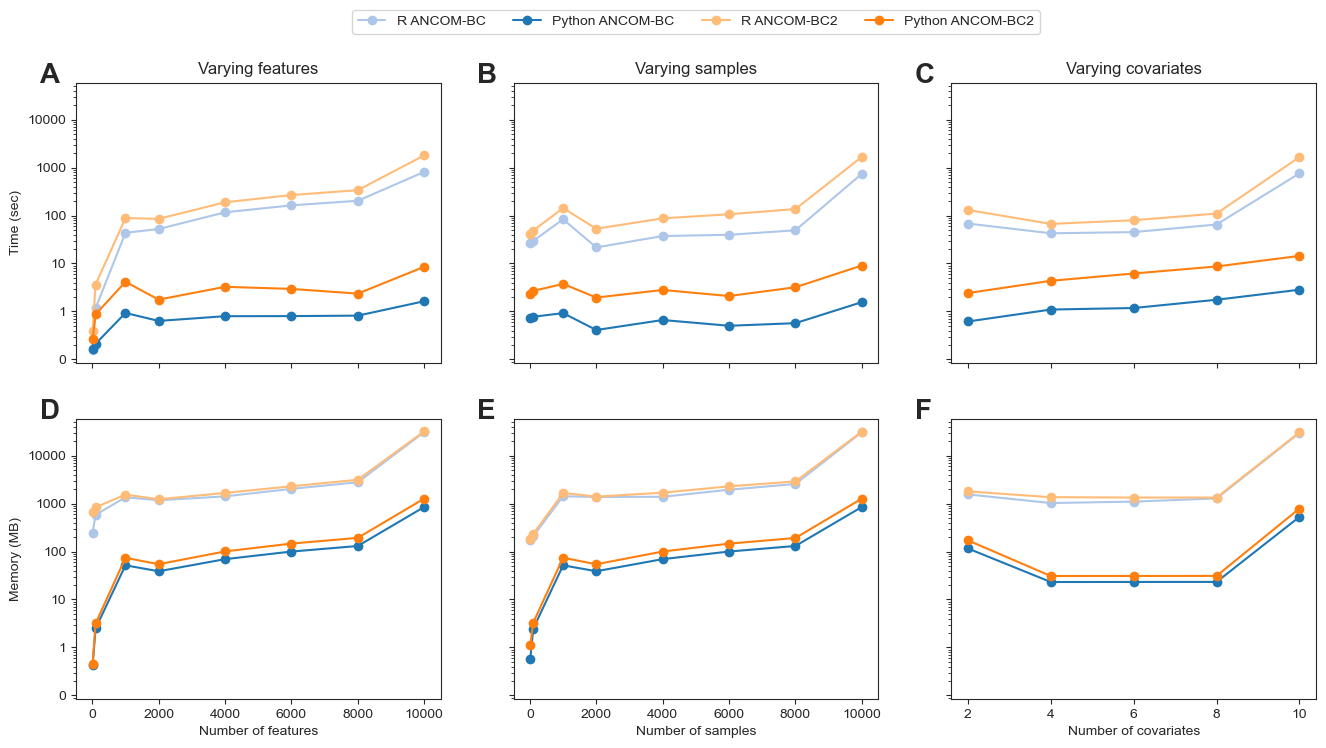

In [5]:
import seaborn as sns
 
#plt.style.use('seaborn-v0_8')
plt.style.use('default')
#sns.set_style("white")
sns.set_style("ticks")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8), sharey=True, sharex='col')

res = pd.read_csv('./benchmark_revision/bench_r_results_pseudo_sens.csv', index_col=0)
res_py = pd.read_csv('./benchmark_revision/bench_py_results_pseudo_sens.csv', index_col=0)
res_py = res_py[res_py.index != 'Full_matrix']
x = np.array([10, 100, 1000, 2000, 4000, 6000, 8000, 10000])

y = []
y_py = []
y_mem = []
y_mem_py = []
y_2 = []
y_py_2 = []
y_mem_2 = []
y_mem_py_2 = []

for i in x:
    y.append(res[(res['Features'] == i) & (res['Impl'] == 'R_ancombc')]['Time_Sec'].mean())
    y_mem.append(res[(res['Features'] == i) & (res['Impl'] == 'R_ancombc')]['Mem_Trace_MB'].mean())
    y_py.append(res_py[(res_py['Features'] == i) & (res_py['Impl'] == 'Py_ancombc')]['Time_Sec'].mean())
    y_mem_py.append(res_py[(res_py['Features'] == i) & (res_py['Impl'] == 'Py_ancombc')]['Mem_Trace_MB'].mean())
    y_2.append(res[(res['Features'] == i) & (res['Impl'] == 'R_ancombc2')]['Time_Sec'].mean())
    y_mem_2.append(res[(res['Features'] == i) & (res['Impl'] == 'R_ancombc2')]['Mem_Trace_MB'].mean())
    y_py_2.append(res_py[(res_py['Features'] == i) & (res_py['Impl'] == 'Py_ancombc2')]['Time_Sec'].mean())
    y_mem_py_2.append(res_py[(res_py['Features'] == i) & (res_py['Impl'] == 'Py_ancombc2')]['Mem_Trace_MB'].mean())

y = np.array(y)
y_py = np.array(y_py)
y_mem = np.array(y_mem)
y_mem_py = np.array(y_mem_py)
y_2 = np.array(y_2)
y_py_2 = np.array(y_py_2)
y_mem_2 = np.array(y_mem_2)
y_mem_py_2 = np.array(y_mem_py_2)

axes[0, 0].plot(x, y, marker='o', label='R ANCOM-BC', color=colors[1])
axes[0, 0].plot(x, y_py, marker='o', label='Python ANCOM-BC', color=colors[0])
axes[0, 0].plot(x, y_2, marker='o', label='R ANCOM-BC2', color=colors[3])
axes[0, 0].plot(x, y_py_2, marker='o', label='Python ANCOM-BC2', color=colors[2])
axes[0, 0].set_title("Varying features")
axes[0, 0].set_yscale('log')
axes[0, 0].yaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].set_ylabel("Time (sec)")


axes[1, 0].plot(x, y_mem, marker='o', label='R ANCOM-BC', color=colors[1])
axes[1, 0].plot(x, y_mem_py, marker='o', label='Python ANCOM-BC', color=colors[0])
axes[1, 0].plot(x, y_mem_2, marker='o', label='R ANCOM-BC2', color=colors[3])
axes[1, 0].plot(x, y_mem_py_2, marker='o', label='Python ANCOM-BC2', color=colors[2])
axes[1, 0].set_xlabel("Number of features")
axes[1, 0].set_ylabel("Memory (MB)")


y = []
y_py = []
y_mem = []
y_mem_py = []
y_2 = []
y_py_2 = []
y_mem_2 = []
y_mem_py_2 = []
for i in x:
    y.append(res[(res['Samples'] == i) & (res['Impl'] == 'R_ancombc')]['Time_Sec'].mean())
    y_mem.append(res[(res['Samples'] == i) & (res['Impl'] == 'R_ancombc')]['Mem_Trace_MB'].mean())
    y_py.append(res_py[(res_py['Samples'] == i) & (res_py['Impl'] == 'Py_ancombc')]['Time_Sec'].mean())
    y_mem_py.append(res_py[(res_py['Samples'] == i) & (res_py['Impl'] == 'Py_ancombc')]['Mem_Trace_MB'].mean())
    y_2.append(res[(res['Samples'] == i) & (res['Impl'] == 'R_ancombc2')]['Time_Sec'].mean())
    y_mem_2.append(res[(res['Samples'] == i) & (res['Impl'] == 'R_ancombc2')]['Mem_Trace_MB'].mean())
    y_py_2.append(res_py[(res_py['Samples'] == i) & (res_py['Impl'] == 'Py_ancombc2')]['Time_Sec'].mean())
    y_mem_py_2.append(res_py[(res_py['Samples'] == i) & (res_py['Impl'] == 'Py_ancombc2')]['Mem_Trace_MB'].mean())
y = np.array(y)
y_py = np.array(y_py)
y_mem = np.array(y_mem)
y_mem_py = np.array(y_mem_py)
y_2 = np.array(y_2)
y_py_2 = np.array(y_py_2)
y_mem_2 = np.array(y_mem_2)
y_mem_py_2 = np.array(y_mem_py_2)

axes[0, 1].plot(x, y, marker='o', label='R ANCOM-BC', color=colors[1])
axes[0, 1].plot(x, y_py, marker='o', label='Python ANCOM-BC', color=colors[0])
axes[0, 1].plot(x, y_2, marker='o', label='R ANCOM-BC2', color=colors[3])
axes[0, 1].plot(x, y_py_2, marker='o', label='Python ANCOM-BC2', color=colors[2])
axes[0, 1].set_title("Varying samples")

axes[1, 1].plot(x, y_mem, marker='o', label='R ANCOM-BC', color=colors[1])
axes[1, 1].plot(x, y_mem_py, marker='o', label='Python ANCOM-BC', color=colors[0])
axes[1, 1].plot(x, y_mem_2, marker='o', label='R ANCOM-BC2', color=colors[3])
axes[1, 1].plot(x, y_mem_py_2, marker='o', label='Python ANCOM-BC2', color=colors[2])
axes[1, 1].set_xlabel("Number of samples")


x = np.array([2, 4, 6, 8, 10])
y = []
y_py = []
y_mem = []
y_mem_py = []
y_2 = []
y_py_2 = []
y_mem_2 = []
y_mem_py_2 = []
for i in x:
    y.append(res[(res['N_Cov'] == i) & (res['Impl'] == 'R_ancombc')]['Time_Sec'].mean())
    y_mem.append(res[(res['N_Cov'] == i) & (res['Impl'] == 'R_ancombc')]['Mem_Trace_MB'].mean())
    y_py.append(res_py[(res_py['N_Cov'] == i) & (res_py['Impl'] == 'Py_ancombc')]['Time_Sec'].mean())
    y_mem_py.append(res_py[(res_py['N_Cov'] == i) & (res_py['Impl'] == 'Py_ancombc')]['Mem_Trace_MB'].mean())
    y_2.append(res[(res['N_Cov'] == i) & (res['Impl'] == 'R_ancombc2')]['Time_Sec'].mean())
    y_mem_2.append(res[(res['N_Cov'] == i) & (res['Impl'] == 'R_ancombc2')]['Mem_Trace_MB'].mean())
    y_py_2.append(res_py[(res_py['N_Cov'] == i) & (res_py['Impl'] == 'Py_ancombc2')]['Time_Sec'].mean())
    y_mem_py_2.append(res_py[(res_py['N_Cov'] == i) & (res_py['Impl'] == 'Py_ancombc2')]['Mem_Trace_MB'].mean())

y = np.array(y)
y_py = np.array(y_py)
y_mem = np.array(y_mem)
y_mem_py = np.array(y_mem_py)
y_2 = np.array(y_2)
y_py_2 = np.array(y_py_2)
y_mem_2 = np.array(y_mem_2)
y_mem_py_2 = np.array(y_mem_py_2)

axes[0, 2].set_title("Varying covariates")
axes[0, 2].plot(x, y, marker='o', label='R ANCOM-BC', color=colors[1])
axes[0, 2].plot(x, y_py, marker='o', label='Python ANCOM-BC', color=colors[0])
axes[0, 2].plot(x, y_2, marker='o', label='R ANCOM-BC2', color=colors[3])
axes[0, 2].plot(x, y_py_2, marker='o', label='Python ANCOM-BC2', color=colors[2])

axes[1, 2].plot(x, y_mem, marker='o', label='R ANCOM-BC', color=colors[1])
axes[1, 2].plot(x, y_mem_py, marker='o', label='Python ANCOM-BC', color=colors[0])
axes[1, 2].plot(x, y_mem_2, marker='o', label='R ANCOM-BC2', color=colors[3])
axes[1, 2].plot(x, y_mem_py_2, marker='o', label='Python ANCOM-BC2', color=colors[2])
axes[1, 2].set_xlabel("Number of covariates")



axes[0, 1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=4)
# ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.15),
#           ncol=2, fancybox=True, shadow=True)
for n, ax in enumerate(axes.flatten() ):
    ax.text(-0.1, 1.0, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold')

#plt.tight_layout()
plt.savefig('./fig1a.svg', format="svg")
plt.show()

### numerical comparison on simulated data

In [6]:
r = pd.read_csv('./benchmark_revision/benchmark_sim_res/ancombc_s_10_f_1000_cov_2.csv', index_col=0)
py = pd.read_csv('./benchmark_revision/benchmark_sim_py/impl_ancombc_s_10_f_1000_cov_2.csv')
r.index = r['diff_abn.taxon']
r = r.rename(columns=lambda x: str(x).removeprefix("diff_abn.").rstrip(".").strip("."))
r = r.iloc[:, -3:]
py = py.pivot(index='FeatureID', columns='Covariate', values='Signif')

In [7]:
py.eq(r).sum().sum() / r.size

np.float64(1.0)

### analysis on real datasets

In [12]:
from skbio.stats.composition._ancombc2 import ancombc, ancombc2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [13]:
def plot_single_cm(exp, obs, title):
    np.set_printoptions(precision=2)
    cm = confusion_matrix(exp.sort_index(axis=1).to_numpy().flatten(), obs.sort_index(axis=1).to_numpy().flatten().astype(bool))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.xlabel('R')
    plt.ylabel('Python')
    plt.show()

In [ ]:
def format_res(df): # df is the output matrix from python implementation
    obs = df["Signif"].unstack()
    obs.columns.name = None
    obs.index.name = "taxon"
    obs = obs.rename(columns={"Intercept": "(Intercept)"})
    for c in obs.columns:
        obs = obs.rename(columns={c: c.replace("[T.", "").replace("]", "")})
    obs = obs.sort_index(axis=1)
    obs = obs.sort_index
    return obs

#### HITChip dataset

In [14]:
pseq = pd.read_csv('./dataset/pseq_feature_table_subset.csv', index_col=0)
meta_data = pd.read_csv('./dataset/pseq_meta_data_subset.csv', index_col=0)

In [15]:
table = pseq.to_numpy().T
meta_data = meta_data.dropna(axis=1, how='any')
meta_data['bmi'] = pd.Categorical(meta_data['bmi'], categories=['obese', 'overweight', 'lean'])

In [16]:
res_py = ancombc(table+1, meta_data, "age + region + bmi", max_iter=100)

In [17]:
obs_pseq = res_py["Signif"].unstack()
obs_pseq.columns.name = None
obs_pseq.index.name = "taxon"
obs_pseq = obs_pseq.rename(columns={"Intercept": "(Intercept)"})
for c in obs_pseq.columns:
    obs_pseq = obs_pseq.rename(columns={c: c.replace("[T.", "").replace("]", "")})

In [18]:
obs_pseq2 = pd.read_csv('./res/pseq_primary_py.csv')
obs_pseq2 = obs_pseq2.pivot(index='FeatureID', columns='Covariate', values='Signif')
for c in obs_pseq2.columns:
    obs_pseq2 = obs_pseq2.rename(columns={c: c.replace("[T.", "").replace("]", "")})
obs_pseq2.drop(columns=['Intercept'], inplace=True)

In [19]:
exp_pseq2 = pd.read_csv('./res/pseq_primary.csv')
exp_pseq2 = exp_pseq2.pivot(index='FeatureID', columns='Covariate', values='Signif')

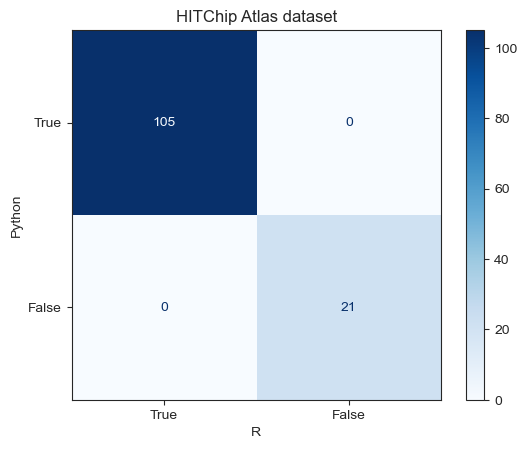

In [20]:
np.set_printoptions(precision=2)
cm = confusion_matrix(exp_pseq2.sort_index(axis=1).to_numpy().flatten(), obs_pseq2.sort_index(axis=1).to_numpy().flatten().astype(bool))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.title("HITChip Atlas dataset")
plt.xlabel('R')
plt.ylabel('Python')
plt.show()

In [21]:
exp_pseq = pd.read_csv('./dataset/pseq_subset_out_res_diff_abn.csv', index_col='taxon').drop("Unnamed: 0", axis=1)

In [22]:
obs_pseq.index = exp_pseq.index

In [23]:
similarity = exp_pseq2.eq(obs_pseq2).sum().sum() / exp_pseq2.size
similarity

np.float64(1.0)

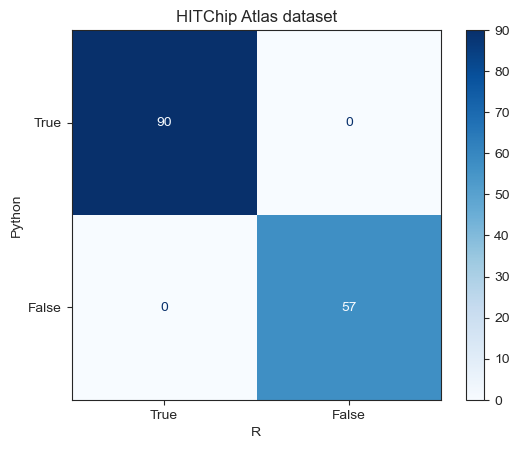

In [24]:
np.set_printoptions(precision=2)
cm = confusion_matrix(exp_pseq.sort_index(axis=1).to_numpy().flatten(), obs_pseq.sort_index(axis=1).to_numpy().flatten().astype(bool))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.title("HITChip Atlas dataset")
plt.xlabel('R')
plt.ylabel('Python')
plt.show()

In [ ]:
np.set_printoptions(precision=2)
cm = confusion_matrix(exp_pseq.sort_index(axis=1).to_numpy().flatten(), obs_pseq.sort_index(axis=1).to_numpy().flatten().astype(bool))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.title("HITChip Atlas dataset")
plt.xlabel('R')
plt.ylabel('Python')
plt.show()

#### EMP500 dataset

the subset of EMP500 contains 753 samples × 8351 features

In [25]:
table = pd.read_csv('./dataset/feature_emp500_subset.csv', index_col=0)
meta_data = pd.read_csv('./dataset/metadata_emp500_subset.csv', index_col=0)
res_py = ancombc(table+1, meta_data, "empo_1")

In [26]:
res_py_2 = ancombc2(table+1, meta_data, "empo_1")

In [28]:
obs_emp = res_py["Signif"].unstack()
obs_emp .columns.name = None
obs_emp .index.name = "taxon"
obs_emp  = obs_emp .rename(columns={"Intercept": "(Intercept)"})
for c in obs_emp .columns:
    obs_emp  = obs_emp .rename(columns={c: c.replace("[T.", "").replace("]", "")})
obs_emp  = obs_emp .sort_index()

In [29]:
obs_emp2 = res_py_2.res["Signif"].unstack()
obs_emp2 .columns.name = None
obs_emp2 .index.name = "taxon"
obs_emp2  = obs_emp2 .rename(columns={"Intercept": "(Intercept)"})
for c in obs_emp2 .columns:
    obs_emp2  = obs_emp2 .rename(columns={c: c.replace("[T.", "").replace("]", "")})
obs_emp2  = obs_emp2 .sort_index()
exp_emp2 = pd.read_csv('./res/emp500_subset_diff_abn_r_2.csv', index_col='taxon').drop("Unnamed: 0", axis=1)
exp_emp2.index = exp_emp2.index.str[1:]
exp_emp2 = exp_emp2.sort_index()
exp_emp2 = exp_emp2.loc[:, exp_emp2.columns.str.startswith('diff_')]
exp_emp2 = exp_emp2.loc[:, ~exp_emp2.columns.str.contains('robust')]
exp_emp2 = exp_emp2.rename(columns=lambda x: str(x).removeprefix('diff_'))

In [30]:
similarity = exp_emp2.eq(obs_emp2).sum().sum() / exp_emp2.size
print(similarity)

1.0


In [31]:
exp_emp = pd.read_csv('./res/emp500_subset_diff_abn_r.csv', index_col='taxon').drop("Unnamed: 0", axis=1)

In [32]:
exp_emp.index = exp_emp.index.str[1:]
exp_emp = exp_emp.sort_index()

In [33]:
similarity = exp_emp.eq(obs_emp).sum().sum() / exp_emp.size
print(similarity)

1.0


#### single cell dataset

In [45]:
table = pd.read_pickle('~/git/ath/dataset/v7_features_downsample_add_ct_train.pkl')

In [46]:
#table.index = sample_id
table = table.iloc[:, :-9]

In [47]:
normalized_matrix = table.to_numpy()
raw_counts = np.expm1(normalized_matrix)
raw_counts = (2 ** normalized_matrix) - 1
raw_counts[raw_counts < 0] = 0
count_table = np.rint(raw_counts).astype(int)

In [48]:
cond = table.index.str.rsplit('_', n=1).str[0]

In [49]:
sample_id = table.index.str.split('_').str[-1]

In [50]:
ct = table.iloc[:, -9:]

In [51]:
ct = ct.idxmax(axis=1).to_numpy()

In [52]:
meta_data = pd.DataFrame({'cond': cond.to_numpy(), 'cell_tpye':ct}, index=sample_id)

In [53]:
res_py = ancombc(count_table+1, meta_data, "cond") # input is sample by feature

In [54]:
res_py_2 = ancombc2(count_table+1, meta_data, "cond") # input is sample by feature

In [55]:
obs = res_py["Signif"].unstack()
obs.columns.name = None
obs.index.name = "gene"
obs = obs.rename(columns={"Intercept": "(Intercept)"})
for c in obs.columns:
    obs = obs.rename(columns={c: c.replace("[T.", "").replace("]", "")})

In [56]:
obs_2 = res_py_2["Signif"].unstack()
obs_2.columns.name = None
obs_2.index.name = "gene"
obs_2 = obs_2.rename(columns={"Intercept": "(Intercept)"})
for c in obs_2.columns:
    obs_2 = obs_2.rename(columns={c: c.replace("[T.", "").replace("]", "")})

In [57]:
exp_2 = pd.read_csv('./res/sc_diff_abn_r_2.csv', index_col='taxon').drop("Unnamed: 0", axis=1)
exp_2 = exp_2.loc[:, exp_2.columns.str.startswith('diff_')]
exp_2 = exp_2.loc[:, ~exp_2.columns.str.contains('robust')]
exp_2 = exp_2.rename(columns=lambda x: str(x).removeprefix('diff_'))

In [58]:
obs_2.index = exp_2.index

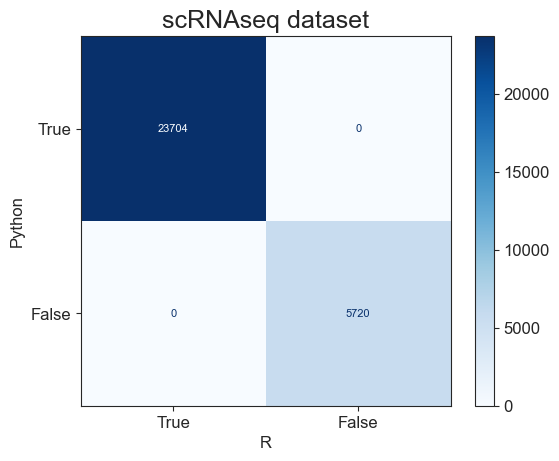

In [379]:
plot_cm(exp, obs, "scRNAseq dataset")

In [380]:
similarity = exp_2.eq(obs_2).sum().sum() / exp_2.size
print(similarity)

1.0


In [60]:
exp = pd.read_csv('./res/sc_diff_abn_r.csv', index_col='taxon').drop("Unnamed: 0", axis=1)

In [61]:
obs.index = exp.index

In [62]:
similarity = exp.eq(obs).sum().sum() / exp.size
print(similarity)

1.0


In [ ]:
# formatting data and save as csv

In [122]:
count_df = pd.DataFrame(count_table, index=table.index, columns=table.columns)

In [148]:
meta_data.index = table.index

In [149]:
count_df.to_csv('./dataset/feature_sc.csv')
meta_data.to_csv('./dataset/metadata_sc.csv')

#### Fig2

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import string

In [36]:
plt.rcParams.update({
    'font.size': 8,          # Base text size
    'axes.titlesize': 18,     # Subplot titles
    'axes.labelsize': 12,     # Axis labels (x/y)
    'xtick.labelsize': 12,    # Ticks numbers
    'ytick.labelsize': 12,
    'legend.fontsize': 8,    # Legend text
    'figure.titlesize': 20    # Main figure title (if any)
})

In [37]:
def plot_cm(ax, matrix, title, subtitle):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["True", "False"])
    
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    
    ax.set_xlabel('R')
    ax.set_ylabel('Python')
    ax.set_title(title, pad=25)
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, 
        ha='center', va='bottom', fontsize=12, color='gray')
    ax.grid(False)

In [38]:
def plot_grouped_bars(ax, data_a, data_b, data_c, data_d, x, title, y_label, has_legend=True):
    rects1 = ax.bar(x - 1.5 * width, data_a, width, label='ANCOM-BC (R)', color=colors[1])
    rects2 = ax.bar(x - 0.5 * width, data_b, width, label='ANCOM-BC (Python)', color=colors[0])
    rects3 = ax.bar(x + 0.5 * width, data_c, width, label='ANCOM-BC2 (R)', color=colors[3])
    rects4 = ax.bar(x + 1.5 * width, data_d, width, label='ANCOM-BC2 (Python)', color=colors[2])
    
    ax.bar_label(rects1, padding=3, fmt='%.2f')
    ax.bar_label(rects2, padding=3, fmt='%.2f')
    ax.bar_label(rects3, padding=3, fmt='%.2f')
    ax.bar_label(rects4, padding=3, fmt='%.2f')

    ax.set_title(title, pad=10)
    ax.set_ylabel(y_label)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    
    # Log scale settings
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

    # Calculate max value across all datasets for upper limit
    max_val = max(max(data_a), max(data_b), max(data_c), max(data_d))
    
    # Note: Log scale cannot have a bottom limit of 0. 
    # Adjust 'bottom' to a small positive number (e.g., 0.1, 1, or min_val) based on your data.
    ax.set_ylim(bottom=0.1, top=max_val * 2) 

    if has_legend:
        ax.legend(loc='upper left')

In [39]:
def plot_all(ax, data, y_label):

    target_colors = {
        'ANCOM-BC (R)': colors[1],
        'ANCOM-BC (Python)': colors[0],
        'ANCOM-BC2 (R)': colors[3],
        'ANCOM-BC2 (Python)': colors[2],
    }
    
    methods = list(data.keys())
    values = list(data.values())

    n_methods = len(methods)
    x = np.arange(n_methods)
    bar_colors = [target_colors.get(method, '#d3d3d3') for method in methods]
    bars = ax.bar(
        x, values, width=0.6,
        capsize=4,
        #edgecolor="black", linewidth=0.5,
        color=bar_colors
    )
    for rect, val in zip(bars, values):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height(),
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=8
        )

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=30, ha="right")

    ax.set_ylabel(y_label)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

In [40]:
def combine_method(r, py, col):
    methods = ['ALDEx2', 'ANCOM-BC (R)', 'ANCOM-BC2 (R)', 'corncob', 'DESeq2', 'edgeR', 'limma', 
           'MaAsLin3', 'metagenomeSeq', 'ZicoSeq', 'ANCOM-BC (Python)', 'ANCOM-BC2 (Python)']
    #rm_methods = ['pyedger', 'orm', 'edgepython']
    rm_methods = ['orm']
    df_r = r.groupby('method')[col].mean().to_dict()
    df_py = py.groupby('method')[col].mean().to_dict()
    combined_df = df_r.copy()
    for key, value in df_py.items():
        if key in combined_df:
            new_key = f"{key} (python)"
            combined_df[new_key] = value
        else:
            combined_df[key] = value

    for i in rm_methods:
        combined_df.pop(i)

    renamed_df = dict(zip(methods, combined_df.values()))
    sorted_df = dict(sorted(renamed_df.items(), key=lambda item: item[1], reverse=True))
    return sorted_df

In [41]:
# runtime_r = all_method_r.groupby('method')['runtime_s'].agg(list).to_dict()
# runtime_py = all_method_py.groupby('method')['runtime_s'].agg(list).to_dict()

In [42]:
def plot_cm(ax, cm, cmap='Blues', show_ylabels=False):
    """Plot a single confusion matrix heatmap (title/subtitle added separately as group labels)."""
    im = ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.max())

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center", color=color, fontsize=10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['True', 'False'])
    ax.set_xlabel('R')

    if show_ylabels:
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['True', 'False'])
        ax.set_ylabel('Python')
    else:
        ax.set_yticks([0, 1])
        ax.set_yticklabels([])   # keep tick marks, drop the True/False text
        ax.set_ylabel('')

    ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)
    return im

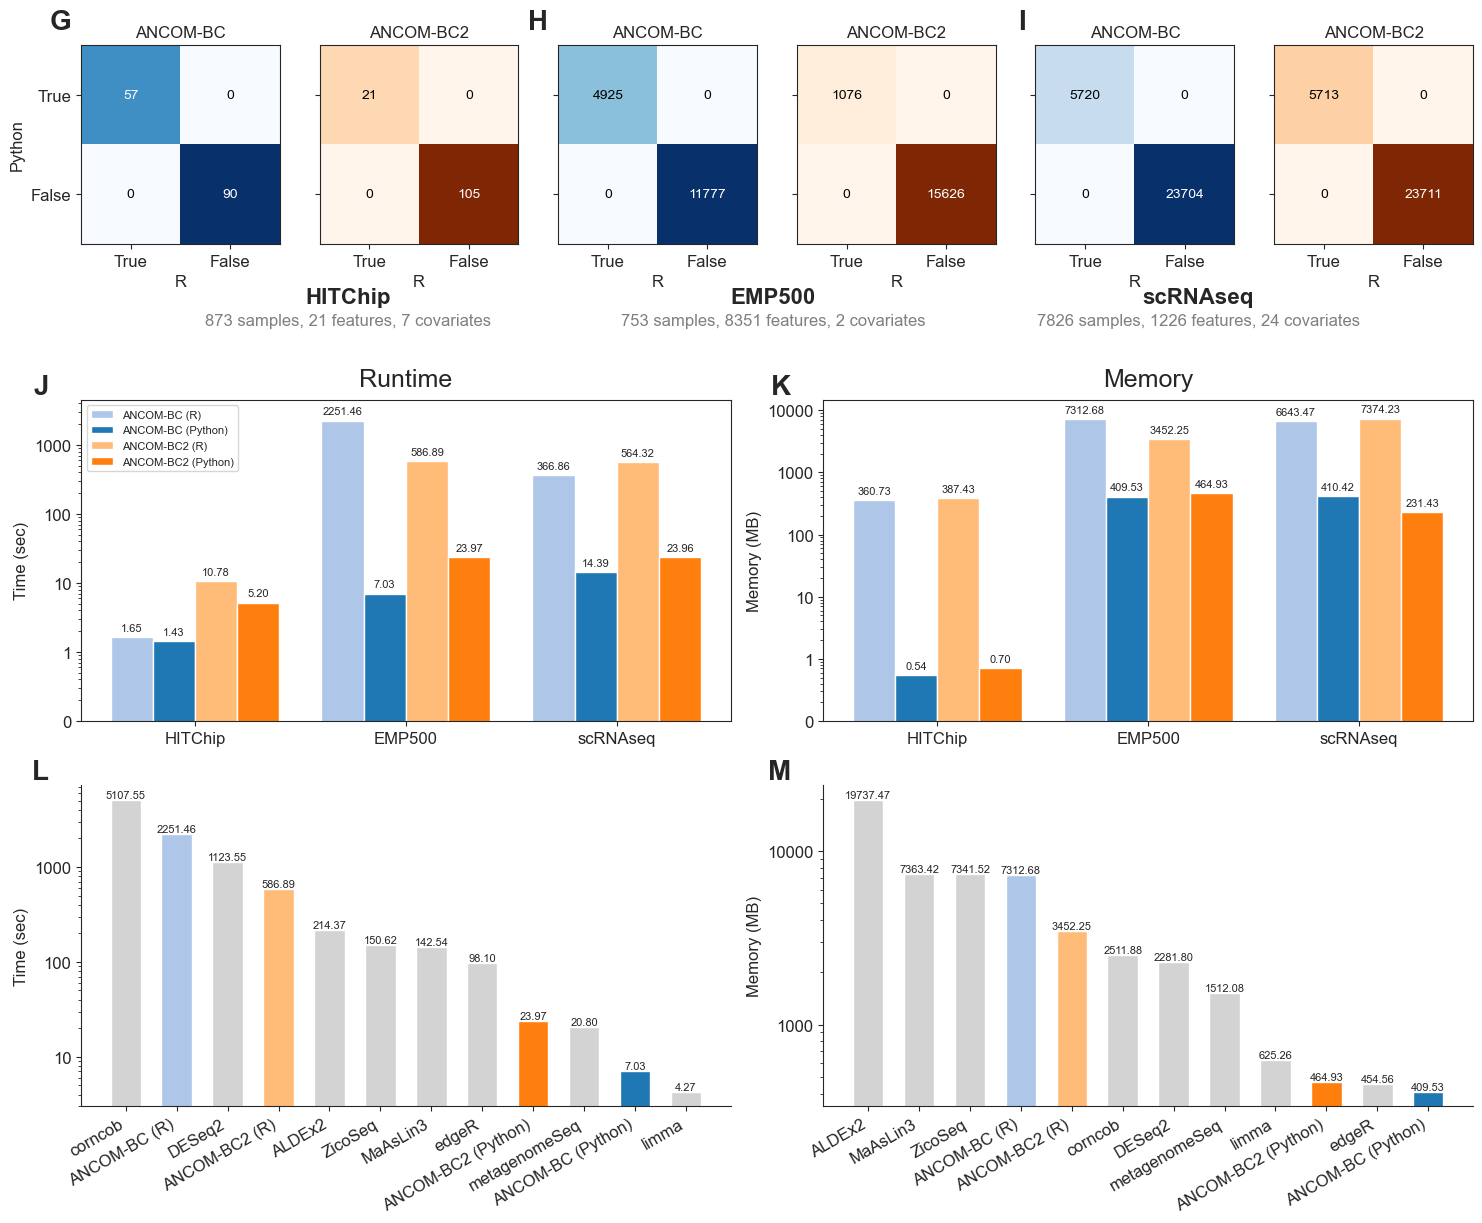

In [65]:
import matplotlib.gridspec as gridspec

groups = ['HITChip', 'EMP500', 'scRNAseq']
subt = ["873 samples, 21 features, 7 covariates",
        "753 samples, 8351 features, 2 covariates",
        "7826 samples, 1226 features, 24 covariates"]
x = np.arange(len(groups))
width = 0.2

# emp500
all_method_r = pd.read_csv('./benchmark_revision/emp500_benchmark_r_all.csv')
all_method_py = pd.read_csv('./benchmark_revision/emp500_benchmark_py_ancombc.csv')
all_method_r = all_method_r[all_method_r['status'] == 'SUCCESS']
runtime_all = combine_method(all_method_r, all_method_py, 'runtime_s')
memory_all = combine_method(all_method_r, all_method_py, 'peak_memory_MB')


s1_dataset_A = [pd.read_csv('./benchmark_revision/benchmark_pseq_r.csv')['Time_Sec'].mean(), 
                all_method_r[all_method_r['method'] =='ancombc']['runtime_s'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_r.csv')['Time_Sec'].mean()]
s1_dataset_B = [pd.read_csv('./benchmark_revision/benchmark_pseq_py.csv')['Time_Sec'].mean(), 
                all_method_py[all_method_py['method'] =='ancombc']['runtime_s'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_py.csv')['Time_Sec'].mean()]
s1_dataset_C = [pd.read_csv('./benchmark_revision/benchmark_pseq_r_pseudo_sens.csv')['Time_Sec'].mean(),
                all_method_r[all_method_r['method'] =='ancombc2']['runtime_s'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_r_pseudo_sens.csv')['Time_Sec'].mean()]
s1_dataset_D = [pd.read_csv('./benchmark_revision/benchmark_pseq_py_pseudo_sens.csv')['Time_Sec'].mean(),
                all_method_py[all_method_py['method'] =='ancombc2']['runtime_s'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_py_pseudo_sens.csv')['Time_Sec'].mean()]

s2_dataset_A = [pd.read_csv('./benchmark_revision/benchmark_pseq_r.csv')['Memory_Used_MB'].mean(), 
                all_method_r[all_method_r['method'] =='ancombc']['peak_memory_MB'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_r.csv')['Memory_Used_MB'].mean()]
s2_dataset_B = [pd.read_csv('./benchmark_revision/benchmark_pseq_py.csv')['Memory_Peak_MB'].mean(), 
                all_method_py[all_method_py['method'] =='ancombc']['peak_memory_MB'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_py.csv')['Memory_Peak_MB'].mean()]
s2_dataset_C = [pd.read_csv('./benchmark_revision/benchmark_pseq_r_pseudo_sens.csv')['Memory_Used_MB'].mean(), 
                all_method_r[all_method_r['method'] =='ancombc2']['peak_memory_MB'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_r_pseudo_sens.csv')['Memory_Used_MB'].mean()]
s2_dataset_D = [pd.read_csv('./benchmark_revision/benchmark_pseq_py_pseudo_sens.csv')['Memory_Peak_MB'].mean(), 
                all_method_py[all_method_py['method'] =='ancombc2']['peak_memory_MB'].mean(),
                pd.read_csv('./benchmark_revision/benchmark_sc_py_pseudo_sens.csv')['Memory_Peak_MB'].mean()]


exp_emp2 = pd.read_csv('./benchmark_revision/emp500_res_r_pseudo_sens.csv', index_col=0)
obs_emp2 = pd.read_csv('./benchmark_revision/emp500_res_py_pseudo_sens.csv', index_col=0)
cm_data = [
    confusion_matrix(exp_pseq.sort_index(axis=1).to_numpy().flatten(), obs_pseq.sort_index(axis=1).to_numpy().flatten().astype(bool), labels=[True, False]),
    confusion_matrix(exp_pseq2.sort_index(axis=1).to_numpy().flatten(), obs_pseq2.sort_index(axis=1).to_numpy().flatten().astype(bool), labels=[True, False]),
    confusion_matrix(exp_emp.sort_index(axis=1).to_numpy().flatten(), obs_emp.sort_index(axis=1).to_numpy().flatten().astype(bool), labels=[True, False]),
    confusion_matrix(exp_emp2.sort_index(axis=1).to_numpy().flatten(), obs_emp2.sort_index(axis=1).to_numpy().flatten().astype(bool), labels=[True, False]),
    confusion_matrix(exp.sort_index(axis=1).to_numpy().flatten(), obs.sort_index(axis=1).to_numpy().flatten().astype(bool), labels=[True, False]),
    confusion_matrix(exp_2.sort_index(axis=1).to_numpy().flatten(), obs_2.sort_index(axis=1).to_numpy().flatten().astype(bool), labels=[True, False])
]


fig = plt.figure(figsize=(16, 13)) 

gs = fig.add_gridspec(3, 6, height_ratios=[1, 1, 1], hspace=0.2, wspace=0.6) 
outer_gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1], hspace=0.6)
row1_gs = gridspec.GridSpecFromSubplotSpec(
    1, 6, subplot_spec=outer_gs[0], wspace=0.1
)
outer_gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1], hspace=0.6)

# Row 1: 6 confusion matrices, narrow wspace
row1_gs = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=outer_gs[0], wspace=0.2)
axes = [fig.add_subplot(row1_gs[0, i]) for i in range(6)]   # <-- FIXED: was gs[0, i]

# mets = ['HITChip', "", 'EMP500', "", 'scRNAseq', ""]
# for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6]):
#     plot_cm(ax, cm_data[i], f"{mets[i]}", subt[i])
#axes = [fig.add_subplot(gs[0, i]) for i in range(6)]
cmaps = ['Blues', 'Oranges', 'Blues', 'Oranges', 'Blues', 'Oranges']
titles = ['ANCOM-BC', 'ANCOM-BC2', 'ANCOM-BC', 'ANCOM-BC2', 'ANCOM-BC', 'ANCOM-BC2']
for i, (ax, cm, cmap) in enumerate(zip(axes, cm_data, cmaps)):
    # Only the very first subplot (leftmost) keeps True/False y-axis labels
    plot_cm(ax, cm, cmap=cmap, show_ylabels=(i == 0))


subplot_titles = ['ANCOM-BC', 'ANCOM-BC2', 'ANCOM-BC', 'ANCOM-BC2', 'ANCOM-BC', 'ANCOM-BC2']
for ax, t in zip(axes, subplot_titles):
    ax.set_title(t, fontsize=12)
# fig.subplots_adjust(left=0.05, right=0.97, top=0.85, bottom=0.28, wspace=0.2)
# fig.canvas.draw()  # finalize axis positions before reading them

# --- Grouped title + subtitle under each pair of subplots ---
pairs = [(axes[0], axes[1]), (axes[2], axes[3]), (axes[4], axes[5])]

for (ax_left, ax_right), title, sub in zip(pairs, groups, subt):
    pos_left = ax_left.get_position()
    pos_right = ax_right.get_position()
    x_center = (pos_left.x0 + pos_right.x1) / 2
    y_top = min(pos_left.y0, pos_right.y0) - 0.01

    fig.text(x_center, y_top, title, ha='center', va='top',
              fontsize=16, fontweight='bold')
    fig.text(x_center, y_top - 0.02, sub, ha='center', va='top',   # <-- was -0.06, now tighter
              fontsize=12, color='gray')



pairs = [(axes[0], axes[1]), (axes[2], axes[3]), (axes[4], axes[5])]
pair_tags = ['G', 'H', 'I']

for (ax_left, ax_right), tag in zip(pairs, pair_tags):
    pos_left = ax_left.get_position()
    ax_left.text(-0.05, 1.05, tag, transform=ax_left.transAxes,
                 fontsize=20, fontweight='bold', va='bottom', ha='right')


# ax1 = fig.add_subplot(gs[0, 0:1])
# ax2 = fig.add_subplot(gs[0, 1:2])
# ax3 = fig.add_subplot(gs[0, 2:3])
# ax4 = fig.add_subplot(gs[0, 3:4])
# ax5 = fig.add_subplot(gs[0, 4:5])
# ax6 = fig.add_subplot(gs[0, 5:6])

ax7 = fig.add_subplot(gs[1, 0:3])
ax8 = fig.add_subplot(gs[1, 3:6])
ax9 = fig.add_subplot(gs[2, 0:3])
ax10 = fig.add_subplot(gs[2, 3:6])



plot_grouped_bars(ax7, s1_dataset_A, s1_dataset_B, s1_dataset_C, s1_dataset_D, x, "Runtime", "Time (sec)")
plot_grouped_bars(ax8, s2_dataset_A, s2_dataset_B, s2_dataset_C, s2_dataset_D, x, "Memory", "Memory (MB)", has_legend=False)


plot_all(ax9, runtime_all, "Time (sec)")
plot_all(ax10, memory_all, "Memory (MB)")


rest_axes = [ax7, ax8, ax9, ax10]
tags = string.ascii_uppercase[9:13]
for ax, tag in zip(rest_axes, tags):
    # Increased fontsize to 24 to keep them dominant
    ax.text(-0.05, 1.00, tag, transform=ax.transAxes, 
            fontsize=20, fontweight='bold', va='bottom', ha='right')

    
# Adjust margins
plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.08)

plt.savefig("./fig1g.png")
plt.show()